In [234]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re 

df = pd.read_csv("../../data/_data.csv")

In [235]:
df = df.drop(columns = ["Unnamed: 0", "Тип", "Метро", "Площадь, м2", "Телефоны", "Описание", "Площадь комнат, м2", "Серия дома", "Высота потолков, м", "Ссылка на объявление"])
df = df.rename(columns = {'ID  объявления': 'id'})

In [236]:
## Вывод числовых значений

def extract_numbers(text, bath_type):
    if pd.isna(text):
        return None
    
    pattern = rf'{bath_type}\s*\((\d+)\)'
    match = re.search(pattern, text)
    
    return int(match.group(1)) if match else 0

## Вывод наличия

def check_text_presence(x, text):
    if pd.isna(x):
        return None
    return 1 if text in str(x) else 0

In [237]:
## Комнаты

df["rooms_count"] = df["Количество комнат"].str.replace(r"[^\d.]", "", regex = True)

df["types_room"] = df["Количество комнат"].str.replace(r"[^\D]", "", regex = True)
df["types_room"] = df["types_room"].str.replace(",", "").str.strip()
df["types_room"] = df["types_room"].replace('', pd.NA)

def check_isolated_room(types_room, rooms_count):
    if pd.isna(types_room):
        return 1 if (rooms_count == "1") else None
    if rooms_count == "2" and 'Оба варианта' in str(types_room):
        return 0
    return 1 if ('Изолированная' in str(types_room) or 'Оба варианта' in str(types_room)) else 0

def check_adjacent_room(types_room, rooms_count):
    if pd.isna(types_room):
        return 0 if rooms_count == "1" else None
    if rooms_count == "1":
        return 0
    if rooms_count == "2" and 'Оба варианта' in str(types_room):
        return 1
    return  1 if ('Смежная' in str(types_room) or 'Оба варианта' in str(types_room)) else 0

df['is_isolated'] = df.apply(lambda row: check_isolated_room(row['types_room'], row['rooms_count']), axis=1)
df['is_adjacent'] = df.apply(lambda row: check_adjacent_room(row['types_room'], row['rooms_count']), axis=1)


# fillna
# fillna



In [238]:
## Дом

df["floor"] = df["Дом"].str.replace(r"[^\d/]", "", regex = True)
floor = df['floor'].str.split('/')
df["floor"] = floor.str[0].astype(int)
df["house_floor"] = floor.str[-1].astype(int)


df["house_type"] = (df["Дом"]
    .str.replace(r'[\d/,]', '', regex=True)
    .str.strip()
    .replace({
        '': pd.NA,
        '- Монолитный': 9,
        'Монолитный': 9,
        'Монолитно-кирпичный': 8,
        'старый фонд': 7,
        'Сталинский': 6,
        'Кирпичный': 5,
        'Газобетонный блок': 4,
        'Деревянный': 3,
        'Щитовой': 2,
        'Блочный': 1,
        'Панельный': 0,
    })
)

# fillna

In [239]:
df["house_type"].unique()

array([9, 8, nan, 0, 6, 5, 7, 1, 3, 4, 2], dtype=object)

In [240]:
## Парковка
df["parking"] = df["Парковка"].replace({'наземная': 0, 'открытая': 1, 'на крыше': 2, 'многоуровневая': 3, 'подземная': 4})


In [241]:
## Ремонт

df["renovation"] = df["Ремонт"].replace({'Без ремонта': 0, 'Косметический': 1, 'Евроремонт': 2, 'Дизайнерский': 3})

# fillna

In [242]:
## Балкон

df['count_loggia'] = df['Балкон'].apply(lambda x: extract_numbers(x, 'Лоджия'))
df['count_balcony'] = df['Балкон'].apply(lambda x: extract_numbers(x, 'Балкон'))

# fillna
# fillna


In [243]:
## Окна

df['view_of_courtyard'] = df['Окна'].apply(lambda x: check_text_presence(x, 'двор'))
df['view_of_street'] = df['Окна'].apply(lambda x: check_text_presence(x, 'улицу'))
# fillna
# fillna

In [244]:
## Санузел


df['combined_bathroom_count'] = df['Санузел'].apply(lambda x: extract_numbers(x, 'Совмещенный'))
df['separate_bathroom_count'] = df['Санузел'].apply(lambda x: extract_numbers(x, 'Раздельный'))

# fillna
# fillna

In [245]:
## Можно с детьми/животными

df['is_child'] = df['Можно с детьми/животными'].apply(lambda x: check_text_presence(x, 'детьми'))
df['is_pet'] = df['Можно с детьми/животными'].apply(lambda x: check_text_presence(x, 'животными'))
# fillna
# fillna

In [246]:
## Дополнительно

df['room_furniture'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Мебель в комнатах'))
df['kitchen_furniture'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Мебель на кухне'))
df['bath'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Ванна'))
df['shower_cabin'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Душевая кабина'))
df['washing_machine'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Стиральная машина'))
df['air_conditioner'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Кондиционер'))
df['dishwasher'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Посудомоечная машина'))
df['tv'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Телевизор'))
df['fridge'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Холодильник'))
df['internet'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Интернет'))
df['telephone'] = df['Дополнительно'].apply(lambda x: check_text_presence(x, 'Телефон'))

# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna

In [247]:
## Лифт 

df['count_passenger_lift'] = df['Лифт'].apply(lambda x: extract_numbers(x, 'Пасс'))
df['count_freight_lift'] = df['Лифт'].apply(lambda x: extract_numbers(x, 'Груз'))

# fillna
# fillna

In [248]:
## Мусоропровод

df["is_garbage_chute"] = df["Мусоропровод"].replace({'Да': 1, 'Нет': 0})

# fillna


In [249]:
## Удаление лишних колонок
df = df.drop(columns =["Мусоропровод", 'Лифт', "Можно с детьми/животными", 'Санузел', 'Окна', 'Балкон', "Ремонт", "types_room", "Количество комнат", "Парковка", "Дополнительно", "Дом"])
df = df.drop(columns =["Адрес", 'Цена', "Название ЖК"])

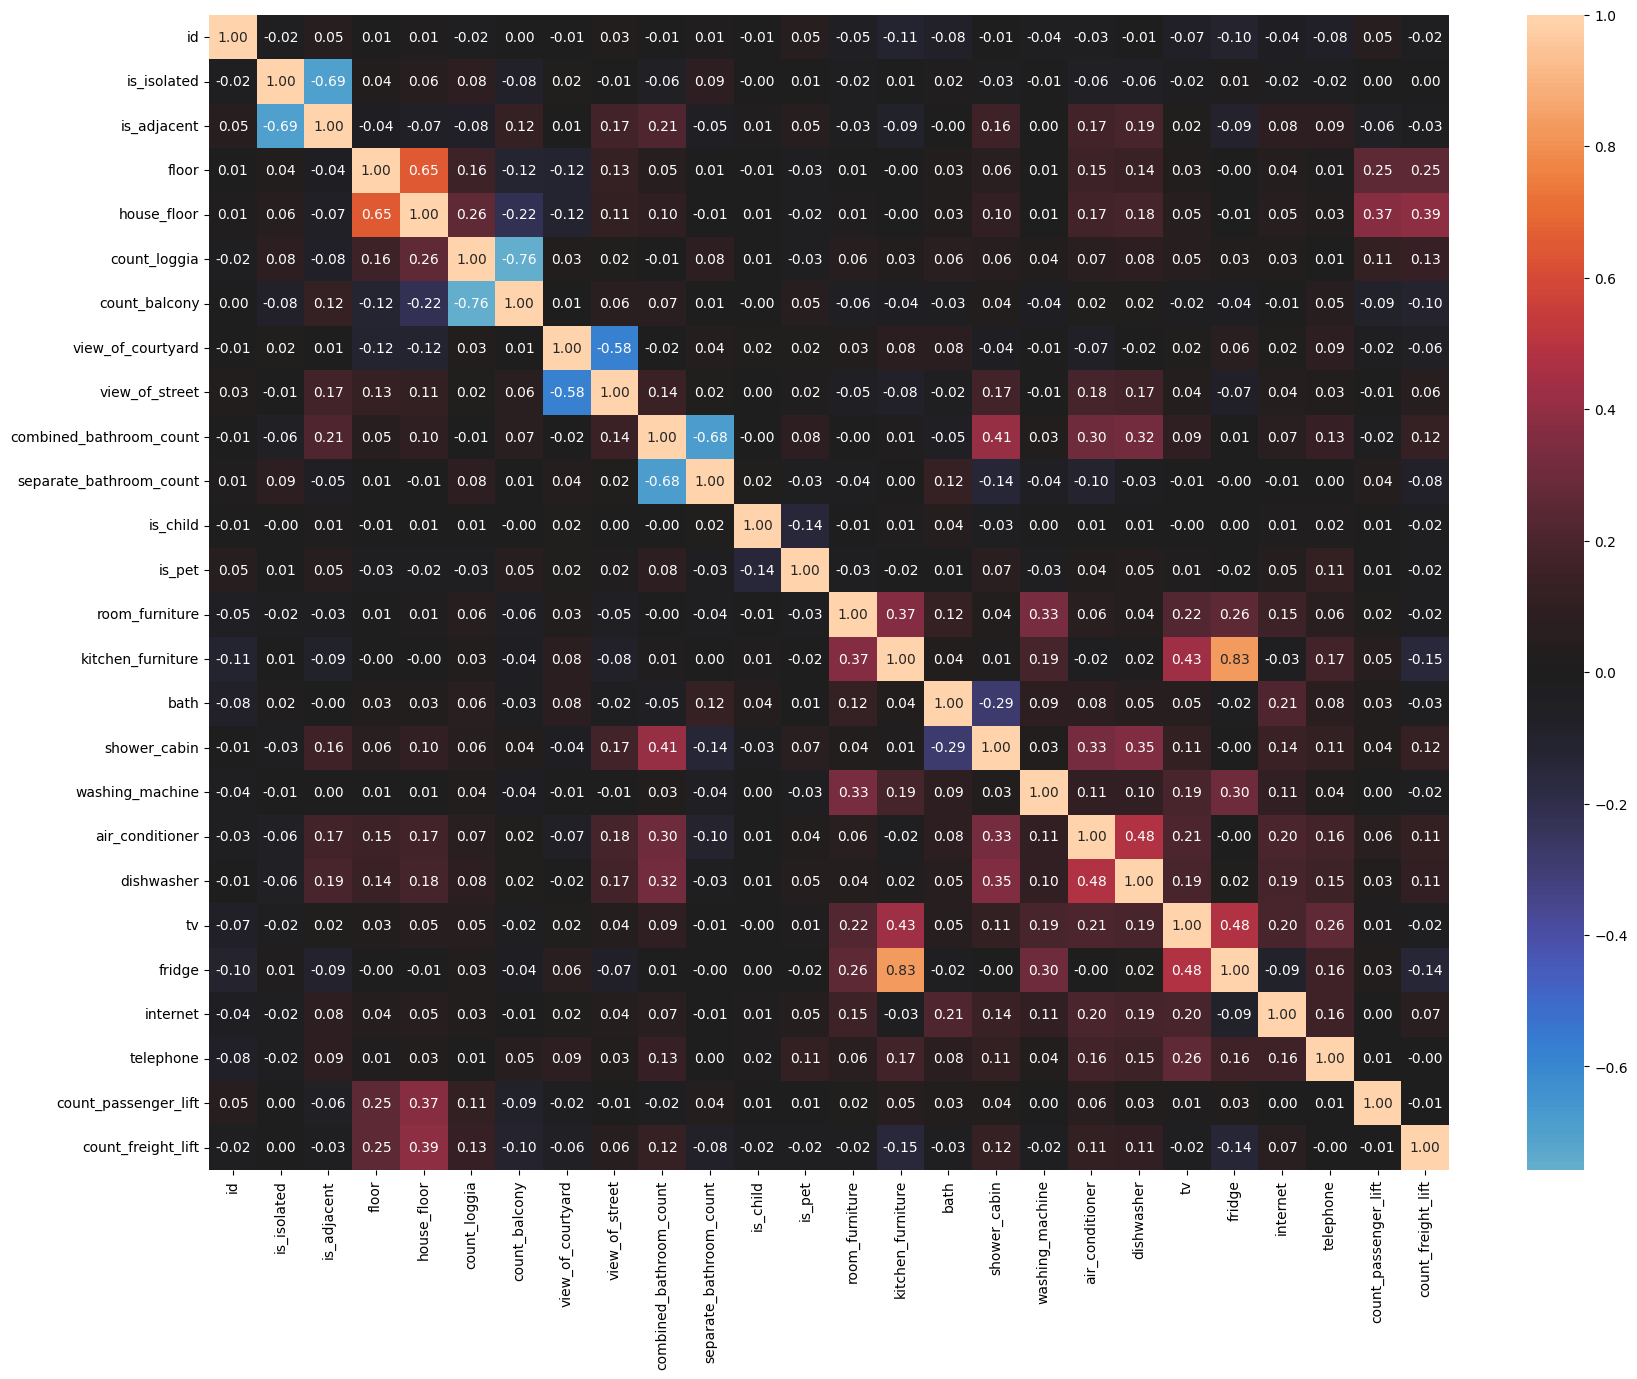

In [250]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(numeric_only = True), annot = True, center = 0, fmt = ".2f");

In [251]:
df.to_csv('../../tmp_data/vanya_processed_part_1.csv', index=False)